<a href="https://colab.research.google.com/github/fajareka1/PCVK_Ganjil_2026_v2/blob/main/Modul_6_Spasial_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [10]:
def convolution2d(image, kernel, strides, padding):
  k_height, k_width = kernel.shape

  if padding > 0:
      padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
  else:
      padded_image = image.copy()

  img_height, img_width = padded_image.shape

  # Menghitung dimensi output
  out_height = int((img_height - k_height) / strides) + 1
  out_width = int((img_width - k_width) / strides) + 1

  output = np.zeros((out_height, out_width), dtype=np.float32)

  # Proses konvolusi
  for y in range(0, out_height):
      for x in range(0, out_width):
          # Mengambil region of interest (ROI)
          y_start = y * strides
          x_start = x * strides
          region = padded_image[y_start:y_start+k_height, x_start:x_start+k_width]

          # Perkalian elemen dan penjumlahan
          output[y, x] = np.sum(region * kernel)

  # Clipping agar nilai piksel tetap berada pada rentang [0, 255]
  output = np.clip(output, 0, 255).astype(np.uint8)
  return output

OG


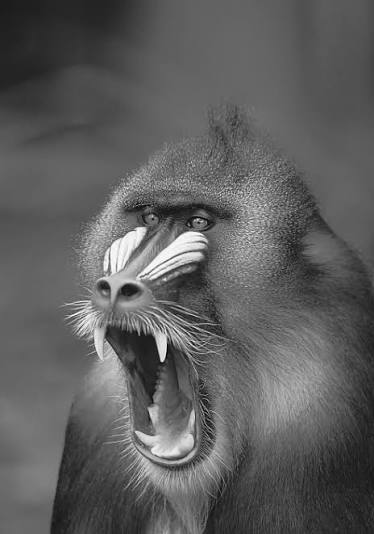

sharphen


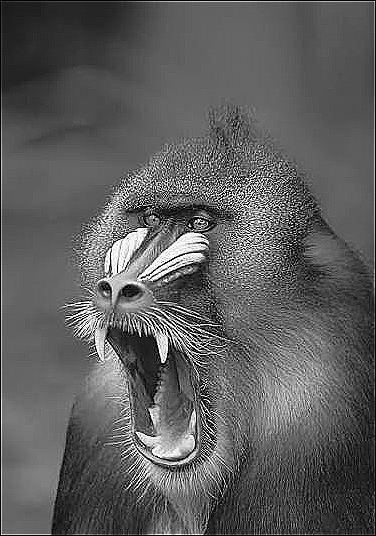

emboss


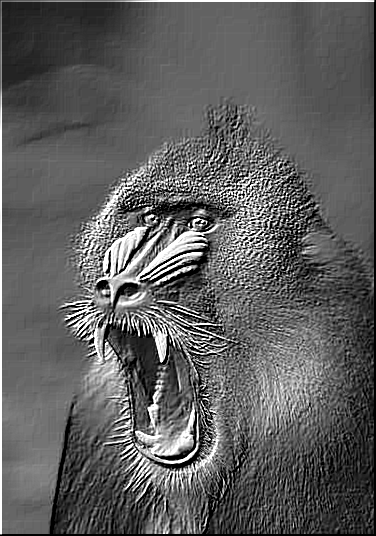

left sobel edge detection


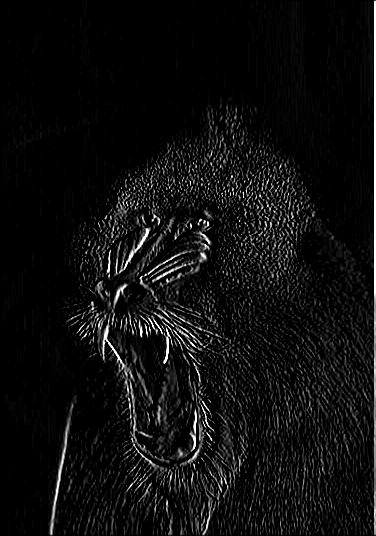

canny edge detection


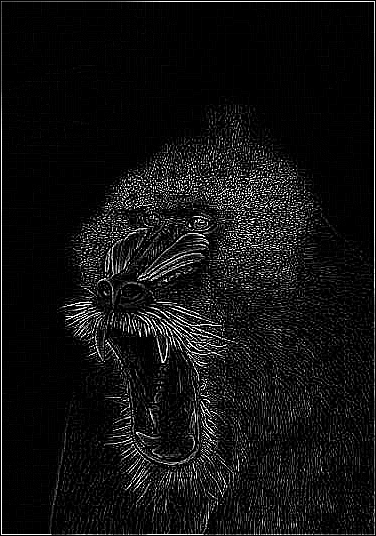

gaussian blur
(534, 374)
kernel_size: 3 | sigma: 1.73


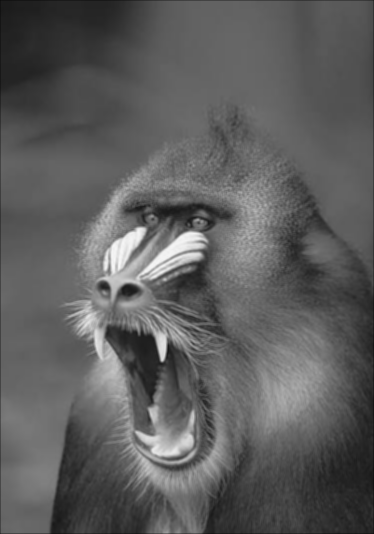

In [14]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print('OG')
cv2_imshow(img_gray)

print('sharphen')
kernel_sharphen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
result_sharp = convolution2d(img_gray, kernel_sharphen, 1, 2)
cv2_imshow(result_sharp)

print('emboss')
kernel_emboss = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])
result_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)
cv2_imshow(result_emboss)

print('left sobel edge detection')
kernel_left_sed = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
result_sobel = convolution2d(img_gray, kernel_left_sed, 1, 2)
cv2_imshow(result_sobel)

print('canny edge detection')
kernel_canny_edge_detection = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
result_canny = convolution2d(img_gray, kernel_canny_edge_detection, 1, 2)
cv2_imshow(result_canny)

print('gaussian blur')

h, w = img_gray.shape
print(img_gray.shape)

# kernel_size menyesuaikan ukuran gambar (~1% sisi terkecil), minimal 3, harus ganjil
kernel_size = max(3, int(min(h, w) * 0.01))
if kernel_size % 2 == 0:
    kernel_size += 1

sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_blur = gaussian_kernel @ gaussian_kernel.transpose()

print('kernel_size:', kernel_size, '| sigma:', round(sigma, 2))

# padding = kernel_size // 2 agar ukuran output tetap sama dengan gambar asli
result_blur = convolution2d(img_gray, kernel_gaussian_blur, 1, kernel_size // 2)
cv2_imshow(result_blur)


In [25]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(image.shape) == 2:
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

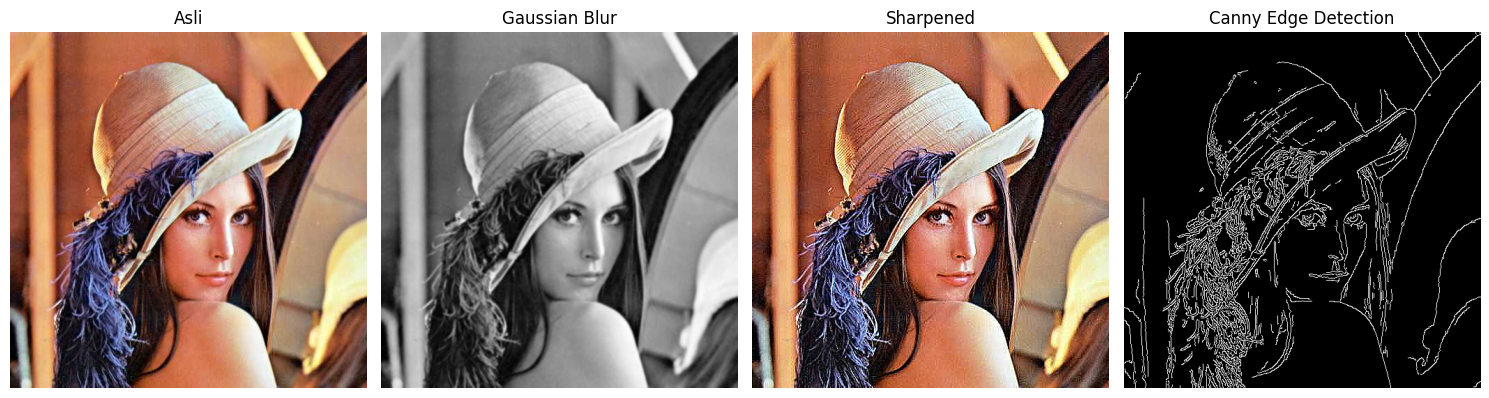

In [26]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpeg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img_gray, (7, 7), 1)
edge = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpen = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpen, edge],
 ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])


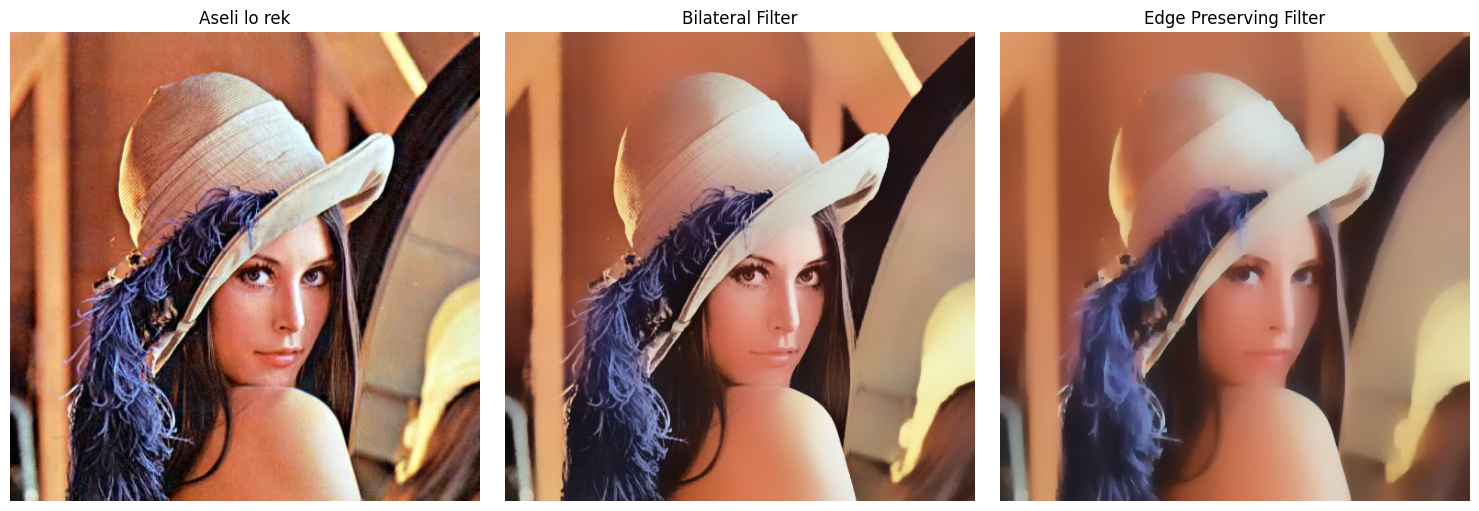

In [27]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags = 1, sigma_s = 100, sigma_r = 0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Aseli lo rek', 'Bilateral Filter', 'Edge Preserving Filter'])

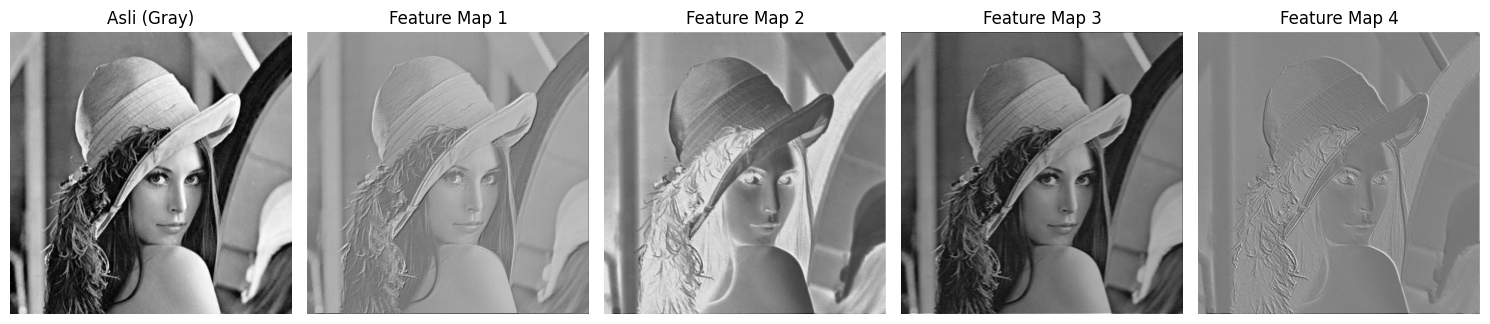

In [28]:
import torch
import torch.nn as nn
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size = 3, stride = 1, padding = 1)

  def forward(self, x):
    x = self.conv1(x)
    return x

model = SimpleCNN()

img_tensor = torch.tensor(img_gray, dtype = torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
  features = model(img_tensor)

feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature Map {i+1}" for i in range(len(feature_maps))])


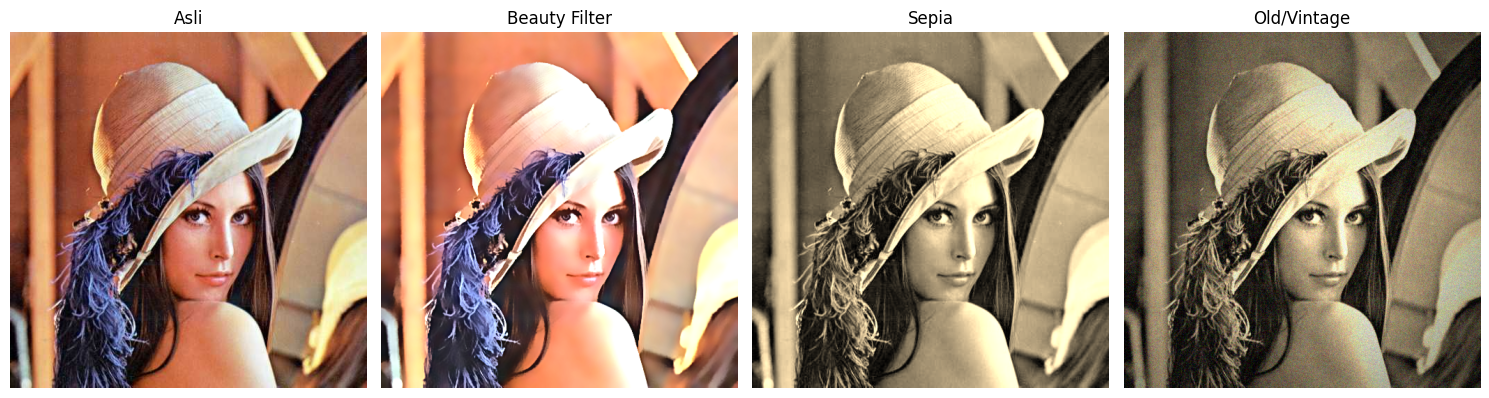

In [30]:
import cv2 as cv
import numpy as np

# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# =====================
# Tampilkan hasil
# =====================
show_side_by_side([img, beauty, sepia, old_img],
                  ["Asli", "Beauty Filter", "Sepia", "Old/Vintage"])

In [36]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(image.shape) == 2:
            plt.imshow(image, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Ganti path sesuai gambar Anda
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpeg')

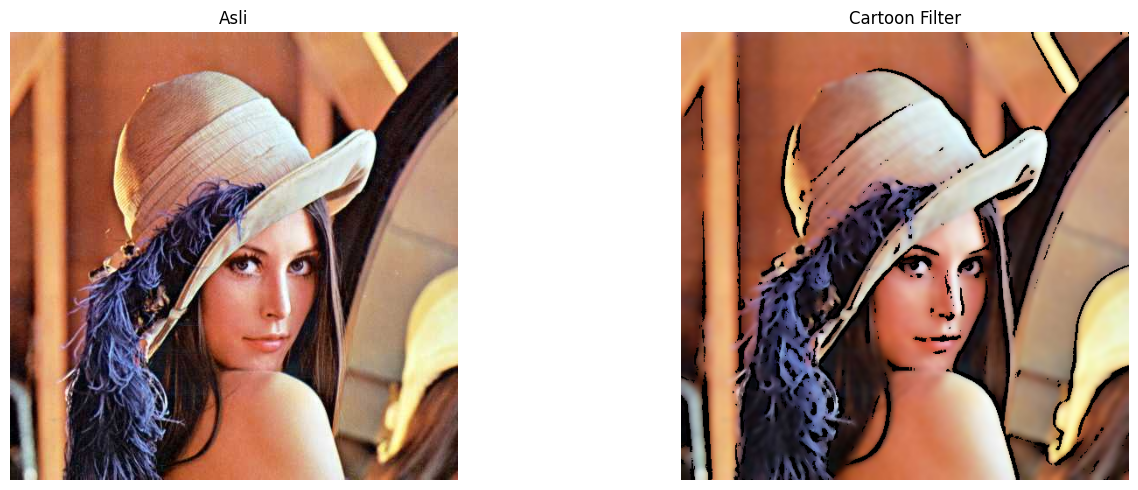

In [37]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

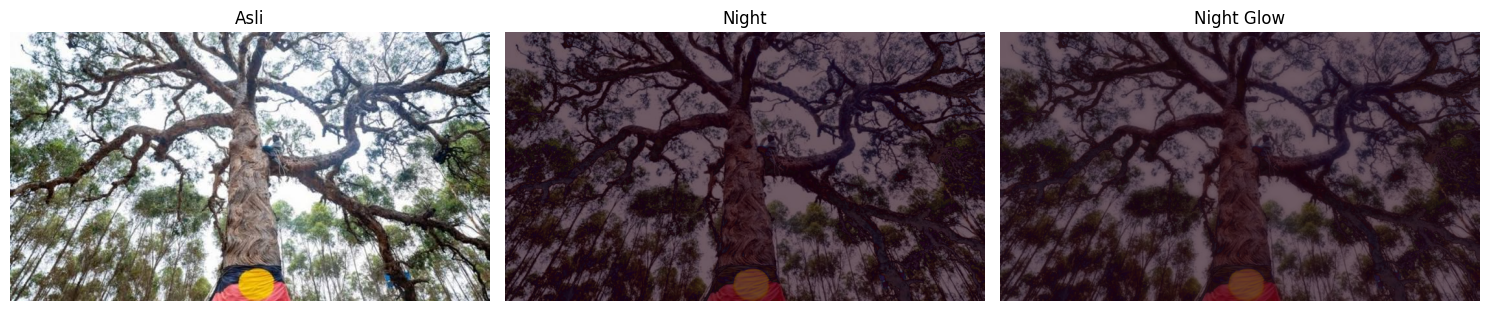

In [38]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/keramat.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


night = cv.convertScaleAbs(img, alpha = 0.6, beta = -40)


blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night,0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Asli", "Night", "Night Glow"])

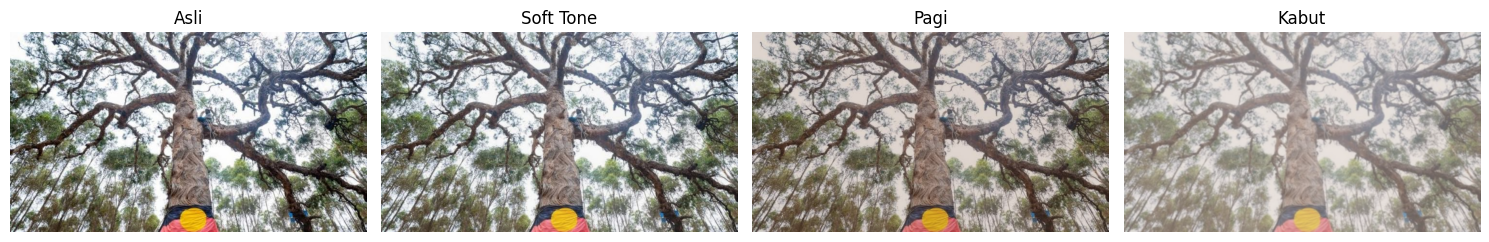

In [40]:
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha =  alpha, beta = beta)

warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(spft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv. filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, spft, pagi, kabut], ["Asli", "Soft Tone", "Pagi", "Kabut"])

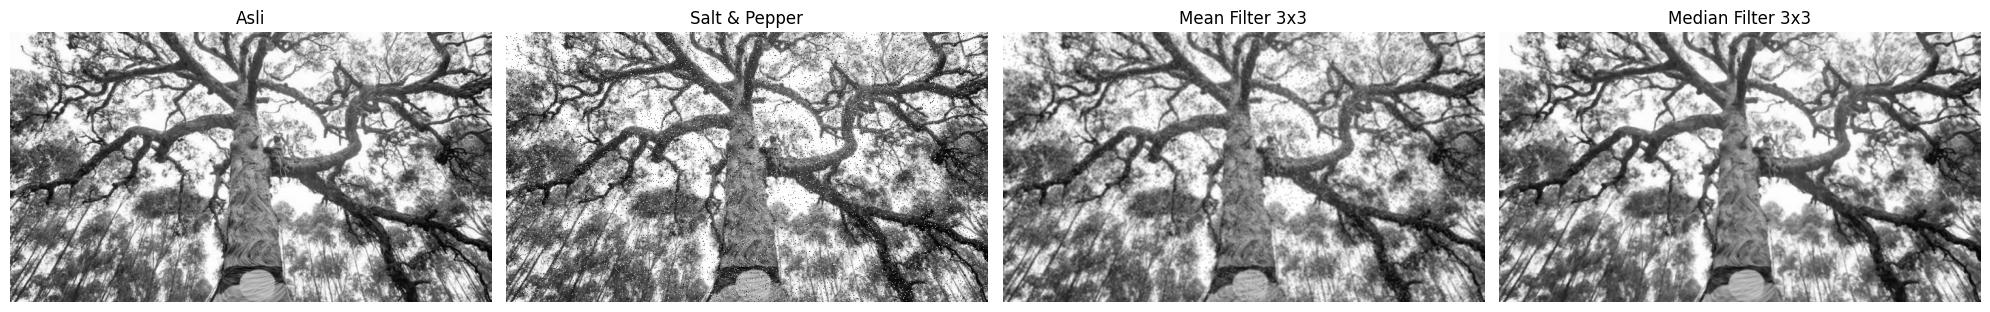

PSNR noisy : 17.86 dB
PSNR mean  : 23.3 dB
PSNR median: 26.46 dB


In [41]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# a. Tambahkan noise salt & pepper
def salt_pepper(image, amount=0.05):
    noisy = image.copy()
    rand = np.random.rand(*image.shape)
    noisy[rand < amount / 2] = 0          # pepper (hitam)
    noisy[rand > 1 - amount / 2] = 255    # salt (putih)
    return noisy

noisy = salt_pepper(gray, amount=0.05)

# b. Mean Filter 3x3 dan Median Filter 3x3
mean_f = cv.blur(noisy, (3, 3))
median_f = cv.medianBlur(noisy, 3)

show_side_by_side([gray, noisy, mean_f, median_f],
                  ["Asli", "Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"],
                  figsize=(20, 5))

# Bukti kuantitatif (PSNR makin tinggi = makin mirip citra asli)
print("PSNR noisy :", round(cv.PSNR(gray, noisy), 2), "dB")
print("PSNR mean  :", round(cv.PSNR(gray, mean_f), 2), "dB")
print("PSNR median:", round(cv.PSNR(gray, median_f), 2), "dB")